In [11]:
import zeus21
from escripts import eMCMC
from escripts import estats
from matplotlib.ticker import MaxNLocator
from escripts import eplots
Plotting = eplots.Plotting()
import importlib
import pandas as pd

In [12]:
# Get data
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/code/home/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

# Gelli+24 comparison

## Run a fit at $z=5$ to estimate the parameters used w/ Gelli+24 parametrization of dsig/dz

In [13]:
# Set hyperparameters
# Metadata table
# Slightly changed Gelli params to fit my parametrization of sigma w/ a "pivot point" at logM = 10
Gelli_params = {'sig': {'fit': False, 'value': 1.1}, 'dsigdM':{'value': -0.34}, 'dlogedM': {'fit': True}}
Gelli_param_data = eMCMC.build_param_data(Gelli_params)

In [14]:
Gelli_UVLF = eMCMC.UVLF(datHST[1], Gelli_param_data)

In [15]:
# Get initial positions for all the walkers by running a short MCMC
Gelli_ICs = Gelli_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [16]:
# Run MCMC
Nsteps=2000
Gelli_UVLF.sampler.run_mcmc(Gelli_ICs, Nsteps) 
# Get flat sample from the MCMC
Gelli_samples = Gelli_UVLF.sampler.get_chain(discard = 400, flat=True)

In [21]:
eMCMC.get_default_dict()

{'alpha': {'fit': True,
  'value': 0.6,
  'start': 0.6,
  'lower': 0,
  'upper': 4,
  'label': '$\\alpha$'},
 'dalphadz': {'fit': False,
  'value': 0,
  'start': 0.01,
  'lower': -0.5,
  'upper': 0.5,
  'label': '$d\\alpha/dz$'},
 'dalphadM': {'fit': False,
  'value': 0,
  'start': 0.01,
  'lower': -0.5,
  'upper': 0.5,
  'label': '$d\\alpha/dM_{h}$'},
 'beta': {'fit': True,
  'value': -0.5,
  'start': -0.5,
  'lower': -1,
  'upper': 0,
  'label': '$\\beta$'},
 'dbetadz': {'fit': False,
  'value': 0,
  'start': 0.01,
  'lower': -0.5,
  'upper': 0.5,
  'label': '$d\\beta/dz$'},
 'dbetadM': {'fit': False,
  'value': 0,
  'start': 0.01,
  'lower': -0.5,
  'upper': 0.5,
  'label': '$d\\beta/dM_{h}$'},
 'logMc': {'fit': True,
  'value': 12,
  'start': 12,
  'lower': 9,
  'upper': 16,
  'label': '$\\log(M_c)$'},
 'dlogMcdz': {'fit': False,
  'value': 0,
  'start': 0.01,
  'lower': -0.5,
  'upper': 0.5,
  'label': '$d\\log(M_c)/dz$'},
 'dlogMcdM': {'fit': False,
  'value': 0,
  'start': 0.01,

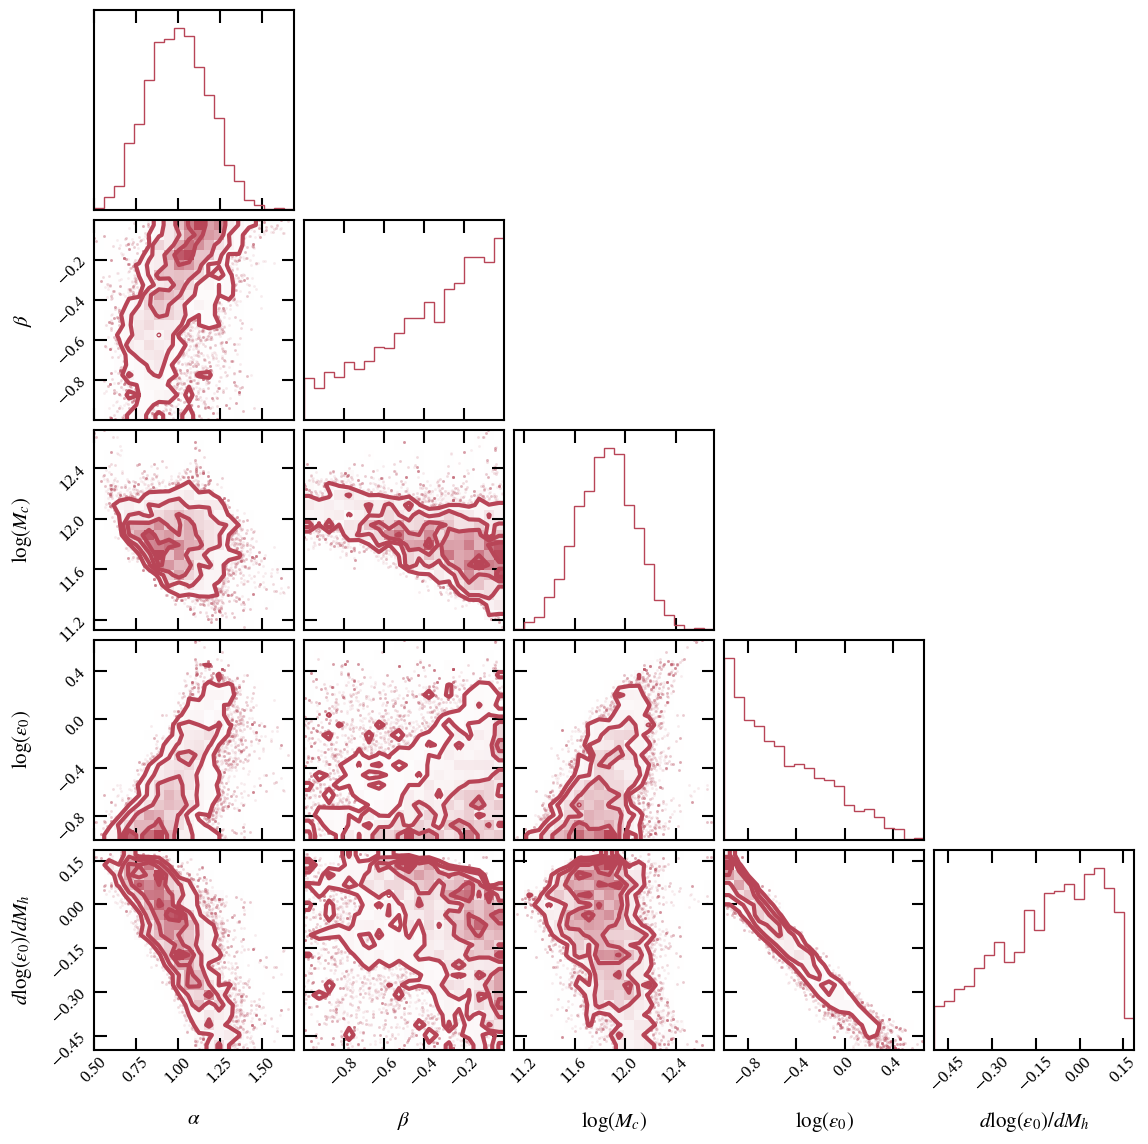

In [23]:
corner = Plotting.plot_corner(Gelli_samples, Gelli_UVLF, excluded_params = ['dlogedM'])

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


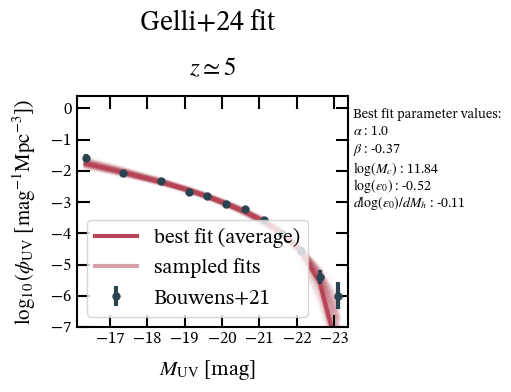

In [18]:
ev_sig = Plotting.plot_evolving_UVLF_fit(Gelli_samples, Gelli_UVLF, title = 'Gelli+24 fit')
#ev_sig.savefig('/Users/eb35267/Desktop/figures/ongoing/Gelli_comparison/tuning_parameters_z5Bouwens.png', bbox_inches = 'tight')

In [22]:
gelli_best = np.average(Gelli_samples, axis = 0)

## Run a fit to get the best fit w/ free dsig/dz

In [24]:
custom_params = {'alpha': {'upper': 1.5}, 'dlogedM': {'fit': True}, 'dsigdM':{'fit':True}}
my_params = eMCMC.build_param_data(custom_params)

In [25]:
my_UVLF = eMCMC.UVLF(datHST[1], my_params)

In [26]:
ICs = my_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [10]:
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 
# Get flat sample from the MCMC
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True)

NameError: name 'my_UVLF' is not defined

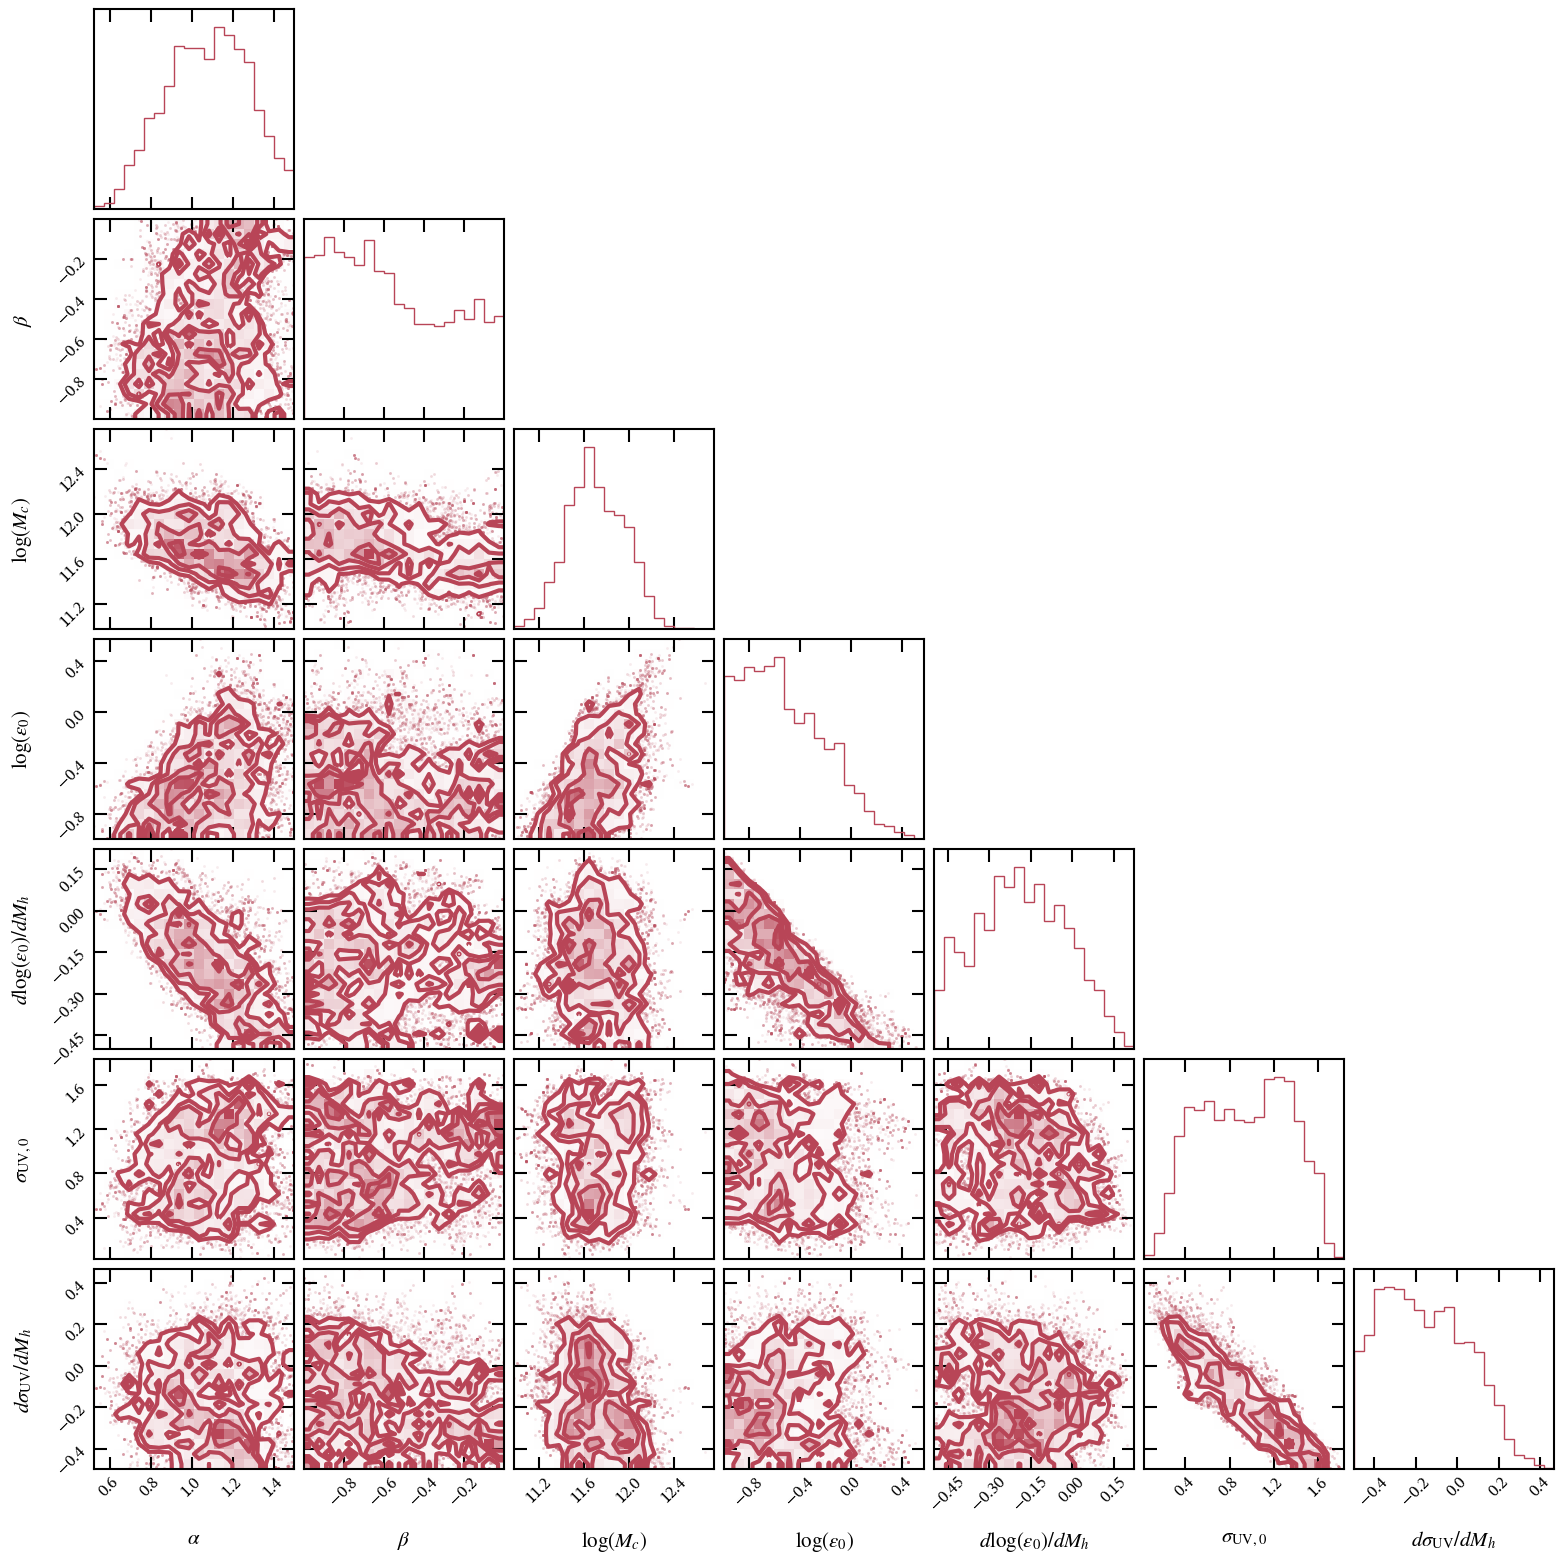

In [30]:
corner = Plotting.plot_corner(samples, my_UVLF)
#corner.savefig('/Users/eb35267/Desktop/figures/ongoing/Gelli_comparison/my_fit_corner.png', bbox_inches = 'tight') 

In [8]:
importlib.reload(eplots)
Plotting = eplots.Plotting()

/Users/eb35267/Desktop/code/home/escripts/eplots.py:165: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')
/Users/eb35267/Desktop/code/home/escripts/eplots.py:217: SyntaxWarning: invalid escape sequence '\c'
  ax[i].plot(xdat, np.log10(currUVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, sample)), label = f'{label}, $\chi^2 = {chi2:.0f}$',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:223: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')


In [9]:
ev_sig = Plotting.plot_evolving_UVLF_fit(samples, my_UVLF, title = r'Fit, free $d\sigma_{\rm{UV}}/dM_{h}$')

NameError: name 'samples' is not defined

In [31]:
my_best = np.average(samples, axis = 0)

## Plot the comparison across $z$

In [34]:
best_fits = [my_best, gelli_best]
labels = [r'MCMC: $\sigma_{\rm{UV}}(M_{h}) = a + b*\log(M_{h}-10)$', 
          r'Gelli+24, $\sigma_{\rm{UV}}(M_{h}) = 1.1 -0.34*\log(M_{h}-10)$']

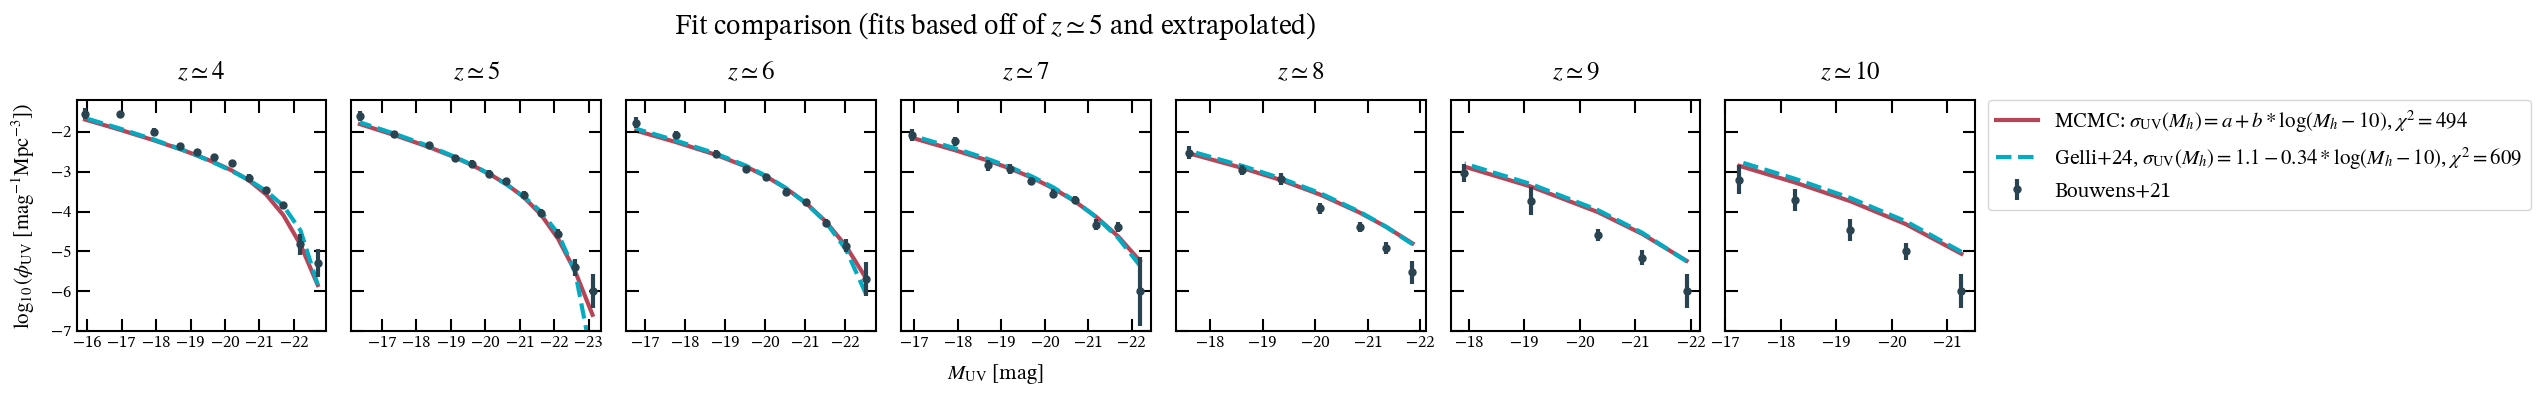

In [35]:
compare = Plotting.compare_fits(datHST, best_fits, labels, [my_UVLF, Gelli_UVLF], 
                                title = r'Fit comparison (fits based off of $z\simeq 5$ and extrapolated)')
#compare.savefig('/Users/eb35267/Desktop/figures/ongoing/Gelli_comparison/compare_over_time.png')

## Make a table

In [38]:
def get_best_fit(samples, param_data, included_params = []):
    best_fit = np.average(samples, axis=0)
    i = 0
    all_vals = []

    for name, param in param_data.items():
        if param.get('fit', False):
            value = best_fit[i]
            i += 1
        else:
            if name in included_params:
                value = param.get('value', None)
            else:
                continue
        all_vals.append(value)

    return all_vals

In [39]:
my_best_fit = get_best_fit(samples, my_params)
included_params = [key for key, param in my_params.items() if param.get('fit', True)]
gelli_best_fit = get_best_fit(Gelli_samples, Gelli_param_data, included_params = included_params)

In [40]:
def make_table(best_fits, param_data, included_params, fit_labels):
    df = pd.DataFrame(best_fits.T.round(2), columns = fit_labels)
    param_labels = [param.get('label') for key, param in param_data.items() if key in included_params]
    df.index = param_labels  # or use df.index = labels

    return df

In [41]:
make_table(np.vstack((my_best_fit, gelli_best_fit)), my_params, included_params, 
           fit_labels = ['$\sigma_{\rm{UV}}(M_{h})$ free', '$\sigma_{\rm{UV}}(M_{h})$ fixed (Gelli+24)'])

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_99988/240627797.py:2: SyntaxWarning: invalid escape sequence '\s'
  fit_labels = ['$\sigma_{\rm{UV}}(M_{h})$ free', '$\sigma_{\rm{UV}}(M_{h})$ fixed (Gelli+24)'])
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_99988/240627797.py:2: SyntaxWarning: invalid escape sequence '\s'
  fit_labels = ['$\sigma_{\rm{UV}}(M_{h})$ free', '$\sigma_{\rm{UV}}(M_{h})$ fixed (Gelli+24)'])


,$\sigma_{\rm{UV}}(M_{h})$ free,$\sigma_{\rm{UV}}(M_{h})$ fixed (Gelli+24)
$\alpha$,1.08,1.00
$\beta$,-0.56,-0.36
$\log(M_c)$,11.70,11.88
$\log(\epsilon_0)$,-0.52,-0.47
$d\log(\epsilon_0)/dM_{h}$,-0.19,-0.12
"$\sigma_{\rm{UV}, 0}$",0.94,1.10
$d\sigma_{\rm{UV}}/dM_{h}$,-0.16,-0.34


# Testing mass dependence across redshift

In [42]:
custom_params = {'dlogedM': {'fit': True}, 'dsigdM':{'fit':True}}
te_params = eMCMC.build_param_data(custom_params)

In [43]:
te_UVLF = eMCMC.UVLF(datHST, te_params)

In [44]:
ICs = te_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [45]:
Nsteps=2000
te_UVLF.sampler.run_mcmc(ICs, Nsteps) 
# Get flat sample from the MCMC
te_samples = te_UVLF.sampler.get_chain(discard = 400, flat=True)

In [48]:
save_dir

'/Users/eb35267/Desktop/figures'

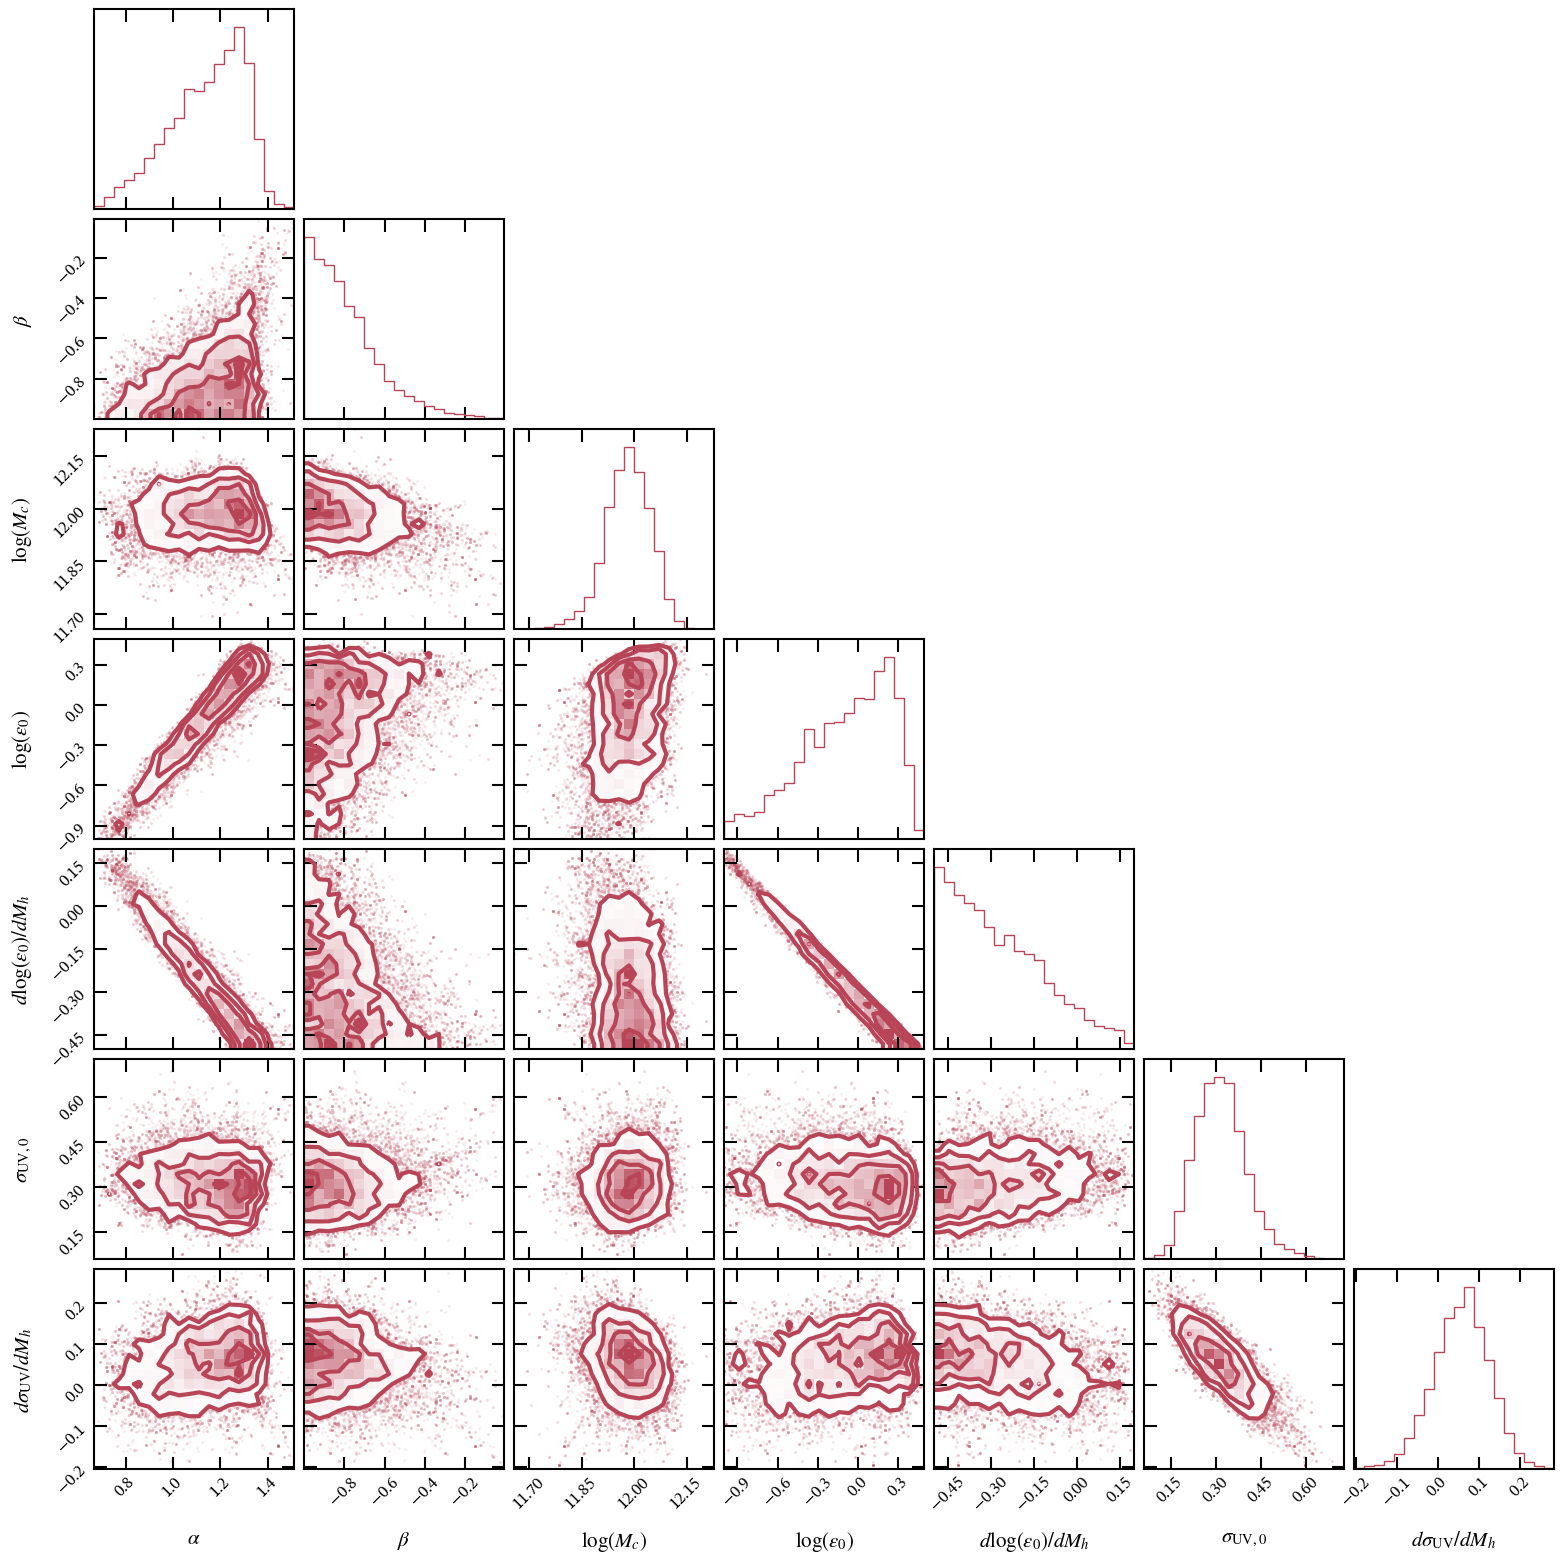

In [49]:
corner = Plotting.plot_corner(te_samples, te_UVLF)
corner.savefig('/Users/eb35267/Desktop/figures/ongoing/mass_evolution/corner.png', bbox_inches = 'tight')

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


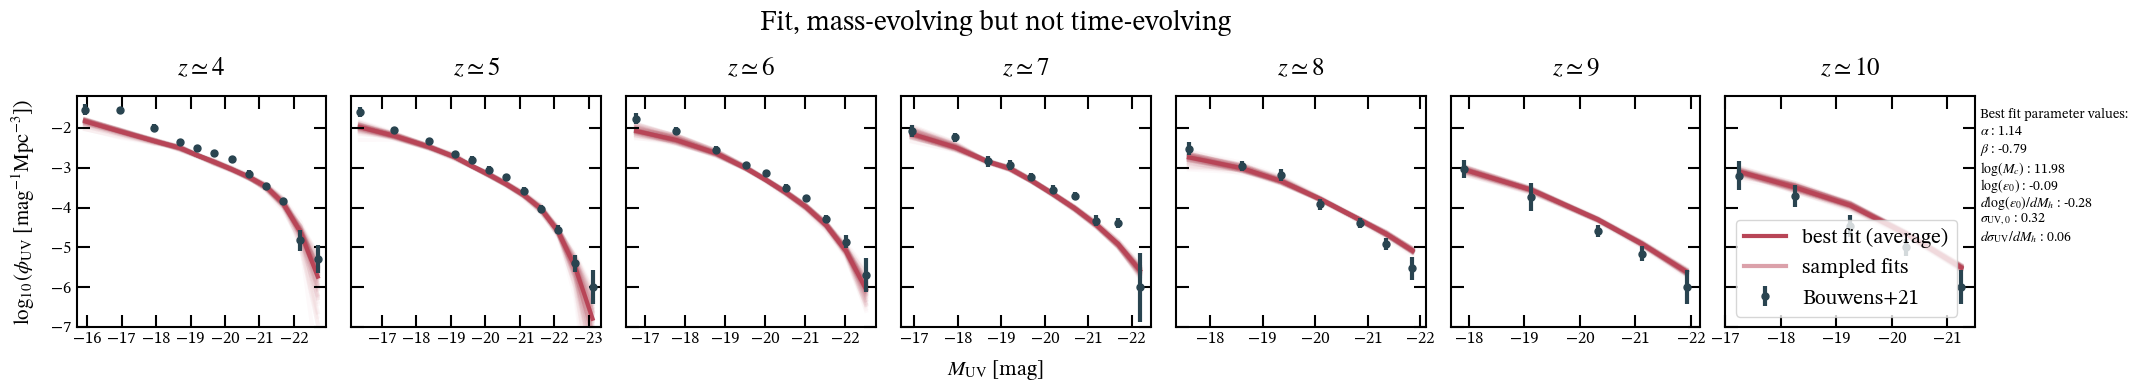

In [50]:
ev_sig = Plotting.plot_evolving_UVLF_fit(te_samples, te_UVLF, title = r'Fit, mass-evolving but not time-evolving')
#ev_sig.savefig('/Users/eb35267/Desktop/figures/ongoing/mass_evolution/fit.png', bbox_inches = 'tight')

# Proving that sigma(M) is working (old)

In [31]:
z = datHST[0][0]
zwidth = datHST[0][1]
MUVcenters = datHST[0][2]
MUVwidth = datHST[0][5]
ydat = datHST[0][3]
yerr = datHST[0][4]

In [32]:
CosmoParams_input = zeus21.Cosmo_Parameters_Input(zmin_CLASS=0.0)
CosmoParams, _, _, HMFintclass =  zeus21.cosmo_wrapper(CosmoParams_input)

In [201]:
evolv_sigUV = (1 + (.5*(np.log10(HMFintclass.Mhtab)-11)))
evolv_sigUV = np.maximum(evolv_sigUV, 0)
astroparams_test = zeus21.Astro_Parameters(CosmoParams,epsstar=10**params1[3], Mc=10**params1[0],alphastar=params1[1], betastar=params1[2], 
                                      sigmaUV = evolv_sigUV)
UVLF_test = zeus21.UVLFs.UVLF_binned(astroparams_test,CosmoParams,HMFintclass,z,zwidth,MUVcenters,MUVwidth)

In [202]:
astroparams_std = zeus21.Astro_Parameters(CosmoParams,epsstar=10**params1[3], Mc=10**params1[0],alphastar=params1[1], betastar=params1[2], 
                                      sigmaUV = 1) 
UVLF_std = zeus21.UVLFs.UVLF_binned(astroparams_std,CosmoParams,HMFintclass,z,zwidth,MUVcenters,MUVwidth)

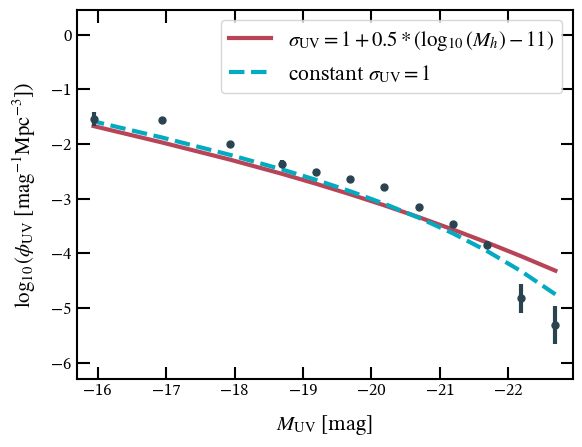

In [205]:
fig, ax = plt.subplots()

ax.plot(MUVcenters, np.log10(UVLF_test), label = r'$\sigma_{\rm{UV}} = 1 + 0.5*(\log_{10}(M_h) - 11)$' )
ax.plot(MUVcenters, np.log10(UVLF_std), label = r'constant $\sigma_{\rm{UV}} = 1$', linestyle = '--')


ax.set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)

ax.errorbar(MUVcenters, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
               color = Plotting.navy)
ax.invert_xaxis()
ax.set_xlim(np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25)
ax.xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')

ax.legend()

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/sigma(M_h).png', bbox_inches = 'tight')